**Nama : Achmad Baharuddin Akbar**

**NIM  : 210411100001**

# Test fuzzy c-means 1

In [120]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [121]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal
0,Gejala Sifilis pada Wanita Berdasarkan Tahapan...,"Rabu, 16 Okt 2024 21:00 WIB",Jakarta - Sifilis atau penyakit raja singa ter...,Kesehatan,Jakarta Sifilis atau penyakit raja singa term...,jakarta sifilis atau penyakit raja singa term...,"['jakarta', 'sifilis', 'atau', 'penyakit', 'ra...",jakarta sifilis penyakit raja singa infeksi me...
1,Puncak Nafsu Pria Ada di Umur Berapa? Studi Bi...,"Rabu, 16 Okt 2024 20:02 WIB",Jakarta - Sebagian orang pasti sudah mengenal ...,Kesehatan,Jakarta Sebagian orang pasti sudah mengenal i...,jakarta sebagian orang pasti sudah mengenal i...,"['jakarta', 'sebagian', 'orang', 'pasti', 'sud...",jakarta orang mengenal istilah puncak seksual ...
2,"Gejala Kanker Mulut yang Kerap Tak Disadari, T...","Rabu, 16 Okt 2024 18:02 WIB",Jakarta - Setiap orang mungkin pernah mengalam...,Kesehatan,Jakarta Setiap orang mungkin pernah mengalami...,jakarta setiap orang mungkin pernah mengalami...,"['jakarta', 'setiap', 'orang', 'mungkin', 'per...",jakarta orang mengalami sariawan luka mulut me...
3,Kapan Waktu yang Tepat untuk Minum Air Rebusan...,"Rabu, 16 Okt 2024 17:31 WIB",Jakarta - Air rebusan serai dikenal sebagai sa...,Kesehatan,Jakarta Air rebusan serai dikenal sebagai sal...,jakarta air rebusan serai dikenal sebagai sal...,"['jakarta', 'air', 'rebusan', 'serai', 'dikena...",jakarta air rebusan serai dikenal salah ramuan...
4,Viral Hanni NewJeans Bicara soal Bullying di T...,"Rabu, 16 Okt 2024 16:34 WIB","Jakarta - Viral momen member NewJeans, Hanni, ...",Kesehatan,Jakarta Viral momen member NewJeans Hanni ber...,jakarta viral momen member newjeans hanni ber...,"['jakarta', 'viral', 'momen', 'member', 'newje...",jakarta viral momen member newjeans hanni berb...


In [122]:
!pip install scikit-fuzzy
# Import libraries yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

In [124]:
texts = df['Filtering/stopword removal']

In [125]:
# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

In [126]:
# Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tfidf_array)

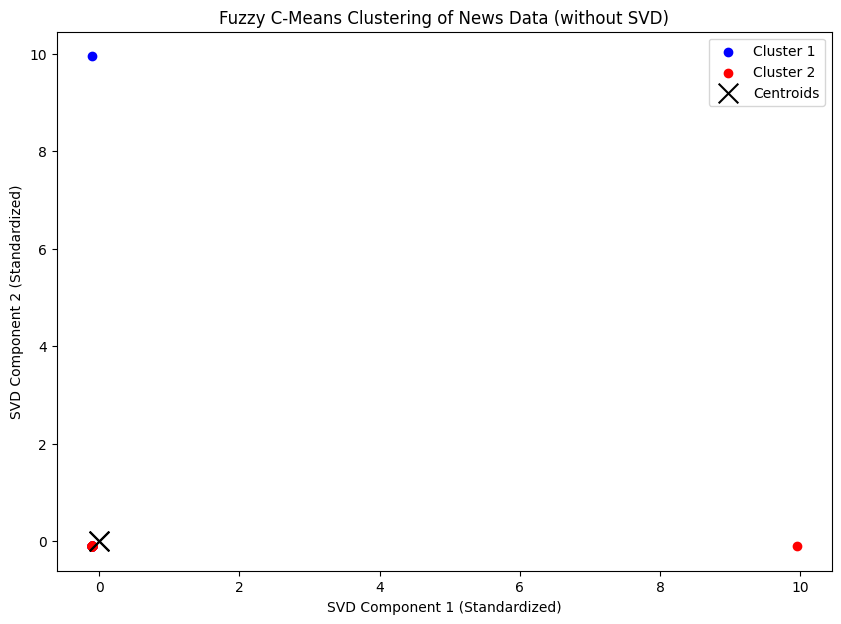

In [127]:
n_clusters = 2  # Jumlah cluster yang diinginkan
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_scaled.T, c=n_clusters, m=2, error=0.001, maxiter=1000, init=None
)

# Menentukan cluster untuk setiap data berdasarkan keanggotaan tertinggi
cluster_labels = np.argmax(u, axis=0)

# Visualisasi hasil klasterisasi
plt.figure(figsize=(10, 7))
colors = ['b', 'r']
for i in range(n_clusters):
    plt.scatter(X_scaled[cluster_labels == i, 0], X_scaled[cluster_labels == i, 1],
                color=colors[i], label=f'Cluster {i+1}')

# Menampilkan pusat cluster
plt.scatter(cntr[:, 0], cntr[:, 1], marker='x', s=200, color='k', label='Centroids')

plt.xlabel('SVD Component 1 (Standardized)')
plt.ylabel('SVD Component 2 (Standardized)')
plt.title('Fuzzy C-Means Clustering of News Data (without SVD)')
plt.legend()
plt.show()

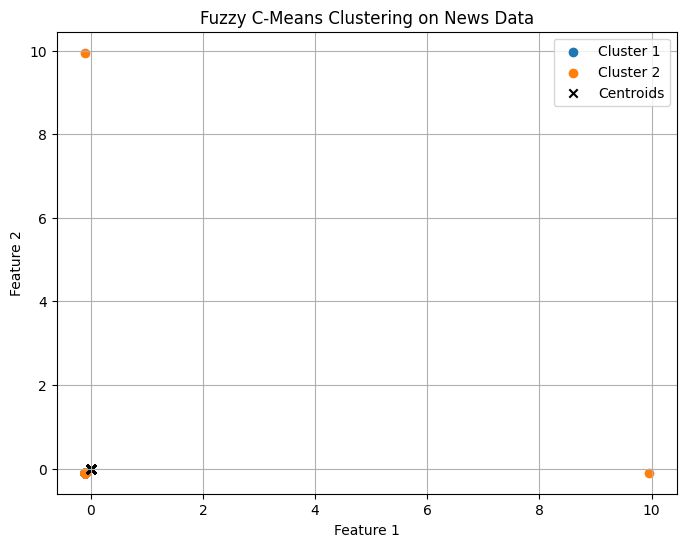

Fuzzy Partition Coefficient (FPC): 0.5000000000050088


In [128]:
# Tentukan jumlah cluster dan parameter fuzziness
n_clusters = 2
m = 2  # Parameter fuzziness

# Terapkan Fuzzy C-Means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T, n_clusters, m, error=0.001, maxiter=1000, init=None
)

# Tentukan keanggotaan cluster
cluster_membership = np.argmax(u, axis=0)

# Visualisasi Hasil Clustering
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(X_scaled[cluster_membership == i, 0], X_scaled[cluster_membership == i, 1], label=f'Cluster {i+1}')

# Tampilkan centroid
plt.scatter(cntr[0], cntr[1], marker='x', color='black', label='Centroids')

plt.title('Fuzzy C-Means Clustering on News Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Evaluasi Hasil
print("Fuzzy Partition Coefficient (FPC):", fpc)


# Test fuzzy c-means 2

In [260]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [261]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal
0,Gejala Sifilis pada Wanita Berdasarkan Tahapan...,"Rabu, 16 Okt 2024 21:00 WIB",Jakarta - Sifilis atau penyakit raja singa ter...,Kesehatan,Jakarta Sifilis atau penyakit raja singa term...,jakarta sifilis atau penyakit raja singa term...,"['jakarta', 'sifilis', 'atau', 'penyakit', 'ra...",jakarta sifilis penyakit raja singa infeksi me...
1,Puncak Nafsu Pria Ada di Umur Berapa? Studi Bi...,"Rabu, 16 Okt 2024 20:02 WIB",Jakarta - Sebagian orang pasti sudah mengenal ...,Kesehatan,Jakarta Sebagian orang pasti sudah mengenal i...,jakarta sebagian orang pasti sudah mengenal i...,"['jakarta', 'sebagian', 'orang', 'pasti', 'sud...",jakarta orang mengenal istilah puncak seksual ...
2,"Gejala Kanker Mulut yang Kerap Tak Disadari, T...","Rabu, 16 Okt 2024 18:02 WIB",Jakarta - Setiap orang mungkin pernah mengalam...,Kesehatan,Jakarta Setiap orang mungkin pernah mengalami...,jakarta setiap orang mungkin pernah mengalami...,"['jakarta', 'setiap', 'orang', 'mungkin', 'per...",jakarta orang mengalami sariawan luka mulut me...
3,Kapan Waktu yang Tepat untuk Minum Air Rebusan...,"Rabu, 16 Okt 2024 17:31 WIB",Jakarta - Air rebusan serai dikenal sebagai sa...,Kesehatan,Jakarta Air rebusan serai dikenal sebagai sal...,jakarta air rebusan serai dikenal sebagai sal...,"['jakarta', 'air', 'rebusan', 'serai', 'dikena...",jakarta air rebusan serai dikenal salah ramuan...
4,Viral Hanni NewJeans Bicara soal Bullying di T...,"Rabu, 16 Okt 2024 16:34 WIB","Jakarta - Viral momen member NewJeans, Hanni, ...",Kesehatan,Jakarta Viral momen member NewJeans Hanni ber...,jakarta viral momen member newjeans hanni ber...,"['jakarta', 'viral', 'momen', 'member', 'newje...",jakarta viral momen member newjeans hanni berb...


In [262]:
!pip install scikit-fuzzy
# Import libraries yang diperlukan
import numpy as np
import pandas as pd
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

In [263]:
texts = df['Filtering/stopword removal']

In [264]:
# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

In [270]:
# Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=20, random_state=42)
data_2d = svd.fit_transform(tfidf_array)

In [271]:
# Normalisasi dengan StandardScaler
scaler = StandardScaler()
data_2d_normalized = scaler.fit_transform(data_2d)

In [272]:
# Tetapkan random seed u
np.random.seed(42)

# Fuzzy C-Means Clustering
n_clusters = 2
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data_2d_normalized.T, c=n_clusters, m=2, error=0.001, maxiter=500, init=None
)

# Menentukan cluster untuk setiap data berdasarkan keanggotaan tertinggi
cluster_labels = np.argmax(u, axis=0)

In [273]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels

# Menampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
print("Jumlah data pada setiap cluster:")
print(cluster_counts)

df_filtered = df[['judul', 'tanggal', 'isi', 'kategori', 'Cluster']]
df_filtered




Jumlah data pada setiap cluster:
Cluster
0    55
1    45
Name: count, dtype: int64


,judul,tanggal,isi,kategori,Cluster
0,Gejala Sifilis pada Wanita Berdasarkan Tahapan...,"Rabu, 16 Okt 2024 21:00 WIB",Jakarta - Sifilis atau penyakit raja singa ter...,Kesehatan,0
1,Puncak Nafsu Pria Ada di Umur Berapa? Studi Bi...,"Rabu, 16 Okt 2024 20:02 WIB",Jakarta - Sebagian orang pasti sudah mengenal ...,Kesehatan,1
2,"Gejala Kanker Mulut yang Kerap Tak Disadari, T...","Rabu, 16 Okt 2024 18:02 WIB",Jakarta - Setiap orang mungkin pernah mengalam...,Kesehatan,0
3,Kapan Waktu yang Tepat untuk Minum Air Rebusan...,"Rabu, 16 Okt 2024 17:31 WIB",Jakarta - Air rebusan serai dikenal sebagai sa...,Kesehatan,1
4,Viral Hanni NewJeans Bicara soal Bullying di T...,"Rabu, 16 Okt 2024 16:34 WIB","Jakarta - Viral momen member NewJeans, Hanni, ...",Kesehatan,1
...,...,...,...,...,...
95,Lamaknyo! Soto Padang Isian Daging Goreng Ada ...,"Selasa, 15 Okt 2024 12:00 WIB",Jakarta - Tak kalah populer dengan jenis soto ...,Kuliner,0
96,Duh! Kedai Lumpia Ini Ditutup 14 Hari Usai Tem...,"Selasa, 15 Okt 2024 11:30 WIB",Jakarta - Kedai yang terkenal dengan hidangan ...,Kuliner,1
97,"Resep Cempedak Goreng Krispi, Manis Renyah Unt...","Selasa, 15 Okt 2024 11:00 WIB",Tentang Bahan Langkah Jakarta - Cempedak yang ...,Kuliner,0
98,10 Tampilan Makanan yang Disebut Buruk Rupa Ta...,"Selasa, 15 Okt 2024 10:30 WIB",Jakarta - Meski tampilan beberapa makanan ini ...,Kuliner,0


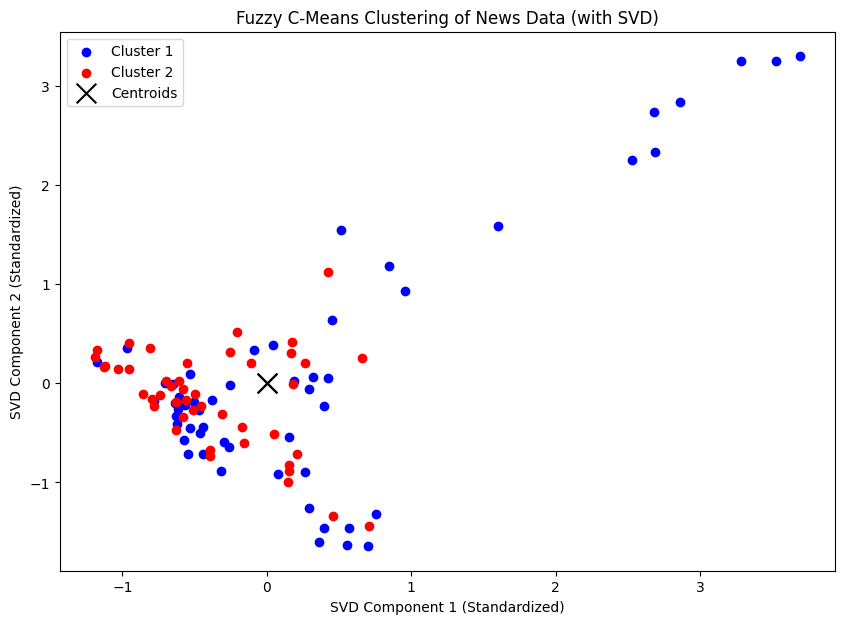

In [274]:
# Visualisasi hasil klasterisasi
plt.figure(figsize=(10, 7))
colors = ['b', 'r']
for i in range(n_clusters):
    plt.scatter(data_2d_normalized[cluster_labels == i, 0], data_2d_normalized[cluster_labels == i, 1],
                color=colors[i], label=f'Cluster {i+1}')

# Menampilkan pusat cluster
plt.scatter(cntr[:, 0], cntr[:, 1], marker='x', s=200, color='k', label='Centroids')

plt.xlabel('SVD Component 1 (Standardized)')
plt.ylabel('SVD Component 2 (Standardized)')
plt.title('Fuzzy C-Means Clustering of News Data (with SVD)')
plt.legend()
plt.show()

# Test fuzzy c-means 3

In [217]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [218]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal
0,Gejala Sifilis pada Wanita Berdasarkan Tahapan...,"Rabu, 16 Okt 2024 21:00 WIB",Jakarta - Sifilis atau penyakit raja singa ter...,Kesehatan,Jakarta Sifilis atau penyakit raja singa term...,jakarta sifilis atau penyakit raja singa term...,"['jakarta', 'sifilis', 'atau', 'penyakit', 'ra...",jakarta sifilis penyakit raja singa infeksi me...
1,Puncak Nafsu Pria Ada di Umur Berapa? Studi Bi...,"Rabu, 16 Okt 2024 20:02 WIB",Jakarta - Sebagian orang pasti sudah mengenal ...,Kesehatan,Jakarta Sebagian orang pasti sudah mengenal i...,jakarta sebagian orang pasti sudah mengenal i...,"['jakarta', 'sebagian', 'orang', 'pasti', 'sud...",jakarta orang mengenal istilah puncak seksual ...
2,"Gejala Kanker Mulut yang Kerap Tak Disadari, T...","Rabu, 16 Okt 2024 18:02 WIB",Jakarta - Setiap orang mungkin pernah mengalam...,Kesehatan,Jakarta Setiap orang mungkin pernah mengalami...,jakarta setiap orang mungkin pernah mengalami...,"['jakarta', 'setiap', 'orang', 'mungkin', 'per...",jakarta orang mengalami sariawan luka mulut me...
3,Kapan Waktu yang Tepat untuk Minum Air Rebusan...,"Rabu, 16 Okt 2024 17:31 WIB",Jakarta - Air rebusan serai dikenal sebagai sa...,Kesehatan,Jakarta Air rebusan serai dikenal sebagai sal...,jakarta air rebusan serai dikenal sebagai sal...,"['jakarta', 'air', 'rebusan', 'serai', 'dikena...",jakarta air rebusan serai dikenal salah ramuan...
4,Viral Hanni NewJeans Bicara soal Bullying di T...,"Rabu, 16 Okt 2024 16:34 WIB","Jakarta - Viral momen member NewJeans, Hanni, ...",Kesehatan,Jakarta Viral momen member NewJeans Hanni ber...,jakarta viral momen member newjeans hanni ber...,"['jakarta', 'viral', 'momen', 'member', 'newje...",jakarta viral momen member newjeans hanni berb...


In [219]:
!pip install scikit-fuzzy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
import skfuzzy as fuzz

In [220]:
# Lakukan preprocessing data menggunakan TF-IDF
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['Filtering/stopword removal']).toarray()

In [221]:
lda = LatentDirichletAllocation(n_components=9)
X_topic = lda.fit_transform(X)

In [222]:
# Implementasikan Fuzzy C-Means menggunakan Fuzzy library
n_clusters = 2
m = 8  # Fuzzy coefficient
max_iter = 1000
tol = 0.05

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(X_topic.T, n_clusters, m, max_iter, tol)

# Dapatkan label cluster untuk setiap data
labels = np.argmax(u, axis=0)

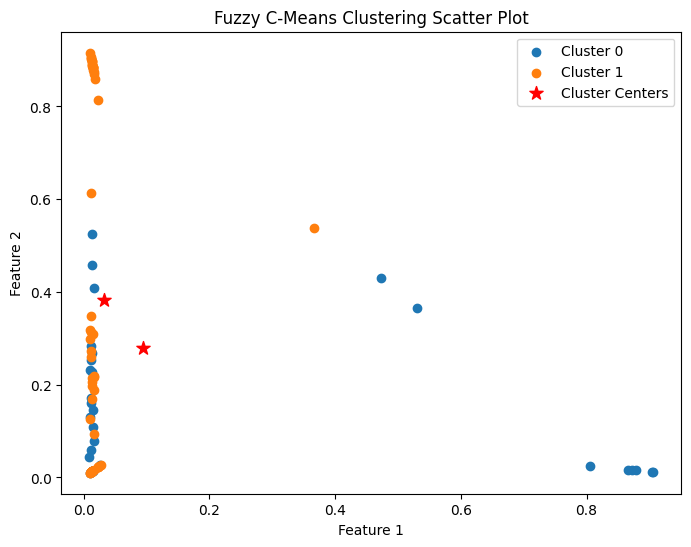

In [223]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Buat plot scatter
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    cluster_data = X_topic[labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {i}')
plt.scatter(cntr[:, 0], cntr[:, 1], s=100, c='red', marker='*', label='Cluster Centers')
plt.title('Fuzzy C-Means Clustering Scatter Plot')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()